In [1]:
import pandas as pd
import numpy as np 
import duckdb
import matplotlib.pyplot as plt
from yelp_sql_extractor import query #within the data base made a fucntion allowing us to easily query a table


c:\Users\Flami\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Yelp data via DuckDB

Important to use Duck DB due to the sheer size of the data set I will be working on. There is a total of 6M rows of yelp reviews within this data set and not only is it huge but its also containing texual reviews that contain 160 characters or more.

### Databases with the data
- Business 
- Checkin
- Review
- tip
- users

### FORMAT for DUCK DB extract
con = connect("**DataBase**")
con.sql()


# Reviews Data

In [2]:
# Peek at the review data — first 100 rows

df_review = query('''
    SELECT *
    FROM review.review
    LIMIT 100
''')
df_review.head(10)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,BY-zkw3lJ4OghDXWjC2AzQ,bdOZza00YtOgFomKfZTVug,Y9ETAKU_4a4yqkKOP-jurw,4.0,0,0,0,My Ford Explorer was serviced at Pep Boys on 0...,2014-06-13 01:25:54
1,FcNbB1nRwrTJnc3hwm4RSA,YUXgVBP5SApSA8Jg-XYHdg,dfKF-oAUf3yjnD0WBYDyZQ,5.0,1,0,0,I hired the Cow and the Curd to come to a bbq ...,2014-07-28 17:46:20
2,Ub80H8C5mTHb5FkMsN8VbA,v6bKaR7Hyt9dfkX5dsldSQ,UCMSWPqzXjd7QHq7v8PJjQ,5.0,1,0,1,Excellent brunch place...could be in LA or San...,2018-02-25 03:13:30
3,c09iHOaS7HdOy_x4g9aR9A,NTCrjLs9bHQTPww2ioecaA,PdMXmOWDRHICAx6SLgu1dQ,4.0,0,0,0,"Good, laid back brunch spot, more casual than ...",2018-02-11 23:00:42
4,aU0q9u4owcy3MTxDqs8Low,C6f720G4P2fV067i3j3XQg,1Pxg1AMf0rEn9QF__ZYoWw,5.0,0,0,0,The sushi was AMAZING! We got great service a...,2014-06-28 23:55:39
5,0B85NOKEMZR3gPyuG7c7bQ,yYASryt2cwZz3olM-iJT7Q,wI51ie-6j7y5MzxOCS4fNA,5.0,0,0,0,I'm a long time fan of Tangelo's. The food is ...,2017-01-03 17:40:10
6,O6K9MEZUn2w_SAss_jAjuw,EXXdXcxflkg9moppilHoCA,RZtGWDLCAtuipwaZ-UfjmQ,3.0,1,1,1,We ate here during Restaurant Week and it was ...,2008-12-05 19:45:00
7,-kL5es9sapkDpgTMeI_09Q,X7JH2HXek83O9AuMD_suFw,x-O0dIeIVaVBEhTu_w56DQ,3.0,0,0,0,better than coco's key. it gets very crowded ...,2016-01-17 22:27:54
8,wYeAU9jINzzA4eg0SDoYwQ,CSx-cOiyUdsjgbe7cqOLbg,RJPRi1pwocHNZr9ISz_P-A,2.0,3,0,0,"To put it as nicely as I can, everything about...",2015-08-20 03:08:28
9,EnCVJsARjzuOFdo3nOKSEw,HTZQHk1oEnhLi2jnHCWmDQ,fnIkeoF_s5DKRieWjWKNiQ,1.0,5,0,0,Was having a pretty epic day until the mc deci...,2015-06-21 23:33:19


In [3]:
print(f"features{df_review.shape[1]}")
print('-'*1000)
print(df_review.info())
del df_review

features9
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [4]:
query('''
    SELECT
        count(*)                                                  AS total_reviews,
        count(*) FILTER (WHERE b.categories ILIKE '%Restaurant%')  AS restaurant_reviews,
        round(100.0 * count(*) FILTER (WHERE b.categories ILIKE '%Restaurant%')
              / count(*), 1)                                       AS pct_restaurant
    FROM review.review   AS r
    JOIN business.business AS b ON r.business_id = b.business_id
''')

,total_reviews,restaurant_reviews,pct_restaurant
0,6990280,4724684,67.6


# Business Data

In [5]:
query("""
    SELECT
        count(*) AS total_businesses,
        count(*) FILTER (WHERE categories ILIKE '%Restaurant%')                 AS restaurants,
        count(*) FILTER (WHERE categories ILIKE '%Restaurant%' AND is_open = 1) AS restaurants_open
    FROM business.business
""")

,total_businesses,restaurants,restaurants_open
0,150346,52286,35004


### NOTE

- The business schema is now filtered to **open restaurants only** (`categories ILIKE '%Restaurant%' AND is_open = 1`) — see the peek query above and the analysis cube below.
- Maybe a future analysis to see if reviews indicate if a store might be heading for permenant closure

# Check In DATA

This data helps us understand whether the business or restaurant that we are looking at is a restaurant that has a lot of foot traffic or not. 

In [6]:
query("""
    SELECT * 
    FROM checkin.checkin
    LIMIT 100
""")

,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."
...,...,...
95,-1hvq_mL4GSEwKE7z8xYug,"2013-04-23 21:03:52, 2013-07-05 21:50:26, 2014..."
96,-1iLbEf1NwY-OJp5Hg-3Sg,"2017-06-08 00:58:45, 2019-09-01 00:26:05"
97,-1m7-ZxGRVRdKa4tFB4eDg,"2014-10-17 18:14:34, 2014-10-29 17:01:04, 2014..."
98,-1owBLC2h6DF5n_j77oq3g,2013-11-01 17:50:33


# NOTE 
- We need to parse the data nad create individual columnsd or sections for the check in times 
- **I Believe we can merge the data with respective individual reviews with the allotted check in time** -- need to further explore this

# Tip DATA

In [7]:
df_tip = query("""
    SELECT * 
    FROM tip.tip
    LIMIT 10000
""")
df_tip

,user_id,business_id,text,date,compliment_count
0,TZVCLnBJVhLWOKUQr64CbQ,ntiIq1FNqduOyyowMFGh5A,Great noodles! Especially knife shaved noodles...,2013-09-15 00:09:34,0
1,nQQq4A-Z1jMRi-1arj55fA,m1oQGgTHWza2rNtT8I5pUQ,Doctor Dan never disappoints. Quick and great ...,2017-12-21 19:46:48,0
2,mXPEZgPYHvboaL5-6yWB-w,Cejsit29ANR9FKEAhq1dXA,"Absolutely excellent service. Reasonable, qui...",2019-01-21 23:55:44,0
3,AVEsJKo7eiVYfMzDGDOMZQ,oGxDifAJKGMLFXSmLAaZDg,Volcano is great! Definitely get the spicy eda...,2019-02-11 00:31:33,0
4,7xdA6oFQnWifNRLLrgEufQ,Hz0p2RasO5tjll-AdjpJqw,Great hidden little gem! Red Beans and Rice wa...,2019-02-16 18:43:04,0
...,...,...,...,...,...
9995,M_-tRHKkYJ51r_a13iWXEw,K7rsFcHcO_LYrgWvTAik2w,Best spot in Nashville,2021-06-24 14:56:54,0
9996,d6iCEHliAbN5gMVxqJe8QA,9ciPosnitacu4xSVSz03mw,The room REEKS of cigarette smoke! Never stay...,2021-05-17 08:45:03,0
9997,Cf5tUENHF3yfjQnSe2RAmQ,rbazT4HNABCj_CeEG7IpNw,Best pizza ! Try Grandma's pie for a real trea...,2021-07-29 19:06:29,0
9998,wDuBehAkxWNfx5Nq8OKpOw,0_2RBo3ZBY6xOef-Ksau1Q,Amazing super quick service at an affordable p...,2015-06-11 17:21:53,0


In [8]:
df_tip["compliment_count"].unique()

array([0, 1, 2])

In [9]:
del df_tip

# NOTE 
- This contains quick reviews or like shoutouts of made by a YELP reviewer. This is good data for additional reviews needed to give us a clearer picture for every restaurant if there are only a few reviews that are present within the data.

# Users DATA

In [10]:
df_user = query("""
    SELECT * 
    FROM users.users
    LIMIT 10000
""")
df_user.head(10)

,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,_IAkGZyZMKhPpIw08mrZvw,Tristyn,286,2010-01-19 05:31:58,1364,545,473,"2012,2013,2014,2015,2016,2017","sw_ncIT7PgslSDjmszWfwQ, amPfWTRlngnKwhyzkiT4HQ...",66,...,10,4,1,1,41,50,55,55,57,7
1,TIlbuLIsGLISCoI9pWlwyQ,Jessica,279,2011-09-24 16:40:18,271,97,143,"2012,2013,2015,2016","yNlLYHKqAwFDLLfNK3UFYA, ci7Q6NvXQ8UZrBHusVX18g...",12,...,2,1,1,0,0,6,13,13,7,0
2,NX2PCi0Kv8RNggx2viw89g,Richard,2,2009-09-22 15:27:02,3,0,1,,"d1jNEyZwuJ7CYnXxwsXaVQ, -HloByMth41DyNpPwMpqrA...",1,...,0,0,0,0,0,0,0,0,0,0
3,zWsGb4AbnxdrjUAWJtNR3w,Dan,70,2008-06-09 04:43:23,102,29,33,,"-1XS_aMVz1NOLMHtpopsDg, hcHGBBp7G--0Agvi0EQRxg...",3,...,1,0,0,0,0,3,0,0,1,0
4,FA0svNuBlW-lDh5f0vRK6g,Jason,67,2011-09-06 19:37:24,171,41,76,"2012,2013","EMJV9rib660I4RpMsbzWbg, fh-Ck0hvK35_rwRKijri7g...",5,...,4,1,0,0,11,10,9,9,7,0
5,i1nCSS5ywyFKpueErvv1eQ,Megan,12,2012-05-30 03:00:48,10,0,1,,"RMmw9iXWv7tMGAOdla5hHw, -KVoZguW-CGPJQnr3YRGqg...",0,...,0,0,0,0,1,2,0,0,0,0
6,gzLY2AO1HwJEwih3yIAb_Q,Emilie,3,2010-08-11 00:12:29,3,0,0,,"nQbgcAxl_uaWFynlpP6GfA, ROF7jQEVF-h1jLUvuGBEHQ...",0,...,0,0,0,0,0,0,0,0,0,0
7,Mf_Ji22D-1XqM4jH-5J9MA,Scott,130,2010-04-04 05:47:38,159,52,38,,"flfj9TAfOWcis21wR2O-LQ, U3HCXRBx6uTcVhx8v4BUIA...",0,...,1,0,0,0,3,2,0,0,0,0
8,3Nc20ZCpwaoAj24HqkuKzA,Michael,21,2010-07-24 01:29:10,66,3,2,,"6zbkFQJ7eBs1DczyiQ1K1Q, ycTvZ2N4obzEA-77U-NQ7Q...",1,...,1,0,0,0,0,0,0,0,0,0
9,ejCRAE4loS8nkZGlapd73A,P,14,2011-03-23 13:25:16,4,2,1,,ET_-rMYJmXJ9i32iI0jomg,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
print(f"# Columns within this dataset: {df_user.shape[1]}")
print("-"*1000)
print(df_user.info())

# Columns within this dataset: 22
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Compliment columns

On Yelp, one user can send another user a **compliment** — a small piece of positive
feedback attached to a person, one of their reviews, or one of their photos. Each
row in `users.users` stores a lifetime **count** of how many compliments of each
type that user has *received*. All 11 columns are non-negative integers (`int64`).

| Column | Yelp label | What it recognises |
|---|---|---|
| `compliment_hot` | *Hot Stuff* | A review the sender thought was hot / exciting |
| `compliment_more` | *Write More* | Sender wants to see more reviews from this user |
| `compliment_profile` | *Great Profile* | The user's profile as a whole |
| `compliment_cute` | *Cute Pic* | The user's profile photo |
| `compliment_list` | *Great Lists* | A list the user curated |
| `compliment_note` | *Just a Note* | A free-form personal note / general shout-out |
| `compliment_plain` | *Thank You* | A plain thank-you, no specific category |
| `compliment_cool` | *You're Cool* | A review tagged cool |
| `compliment_funny` | *You're Funny* | A review tagged funny |
| `compliment_writer` | *Good Writer* | The quality of the user's writing |
| `compliment_photos` | *Great Photo* | A photo the user posted |

### Notes
- These are **received** counts (social recognition earned), not compliments sent.
- Don't confuse them with the `useful` / `funny` / `cool` columns on the same
  table — those are the **totals of review-level votes** across all of the user's
  reviews, and with the per-review `useful` / `funny` / `cool` in `review.review`.
- For this project they're most useful bundled into a **reviewer-credibility /
  influence score** (together with `fans`, `elite`, `review_count`) so a review
  from a well-regarded reviewer can be weighted more heavily when predicting a
  restaurant's trajectory. Most users have zeros across the board, so consider a
  simple `total_compliments` sum or a log transform rather than 11 sparse features.


# Data Analysis 

Finding any obvious signs we can pick up on that can help us decide where we want to head with the Restaurant revieiws data

# First Step: Creating the data cube for analysis

In [12]:
df = query("""
    SELECT
    b.business_id, b.name, b.city, b.state,
    b.stars AS business_avg_stars, b.review_count AS business_review_count,
    r.review_id, r.stars AS review_stars, r.date AS review_date, r.text as review_text,
    u.user_id, u.name AS user_name, u.average_stars AS user_avg_stars, u.fans,
    coalesce(t.tip_count, 0) AS business_tip_count,
    coalesce(c.checkin_count, 0) AS business_checkin_count
    FROM business.business AS b
    JOIN review.review AS r
        ON r.business_id = b.business_id
    JOIN users.users AS u
        ON u.user_id = r.user_id
    LEFT JOIN (
        SELECT business_id, count(*) AS tip_count
        FROM tip.tip
        GROUP BY business_id
    ) AS t ON t.business_id = b.business_id
    LEFT JOIN (
        SELECT business_id, len(string_split(date, ', ')) AS checkin_count
        FROM checkin.checkin
    ) AS c ON c.business_id = b.business_id
    WHERE b.categories ILIKE '%Restaurant%'
    AND b.is_open = 1
""")
print(f"Data Shape: {df.shape}")
print(f"Data info: {df.info()}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data Shape: (3773964, 16)
<class 'pandas.DataFrame'>
RangeIndex: 3773964 entries, 0 to 3773963
Data columns (total 16 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   business_id             str           
 1   name                    str           
 2   city                    str           
 3   state                   str           
 4   business_avg_stars      float64       
 5   business_review_count   int64         
 6   review_id               str           
 7   review_stars            float64       
 8   review_date             datetime64[us]
 9   review_text             str           
 10  user_id                 str           
 11  user_name               str           
 12  user_avg_stars          float64       
 13  fans                    int64         
 14  business_tip_count      int64         
 15  business_checkin_count  int64         
dtypes: datetime64[us](1), float64(3), int64(4), str(8)
memory usage: 2.7 GB
Dat

In [13]:
df.head(10)

,business_id,name,city,state,business_avg_stars,business_review_count,review_id,review_stars,review_date,review_text,user_id,user_name,user_avg_stars,fans,business_tip_count,business_checkin_count
0,fOfP8ILlwlhLknPS59K04A,Dairy Cottage,Springfield,PA,4.0,76,7wn4gvMqoClAmpB_x2XcRA,5.0,2019-09-18 23:51:04,"Highly recommend the Grilled Turkey, Bacon, an...",p5AiVi1KFbmo0Y8ra0CT8g,Amanda,5.00,0,14,157
1,3YqUe2FTCQr0pPVK8oCv6Q,Columbia Restaurant,Tampa,FL,4.0,2860,CmFRkB9CZbchLcB5egWlJw,2.0,2019-02-26 23:05:30,What is all the hype about? Really? I have h...,AtTrKfSvs_NNrCkNkgGfEA,Sharon,2.86,0,279,4476
2,uXziexv0fsfRMw1hEdifow,Pasta Pomodoro,Sewell,NJ,4.0,68,7bm-ukWR5l8adUwVzrF6YQ,5.0,2020-10-21 19:44:05,The staff is always so friendly. We order take...,uI0AaW0XgsnxVwJ9d9bqfw,Abby,4.95,1,6,36
3,TdrNka-oPWf4B-jN9rKltw,Bok Bar,Philadelphia,PA,4.0,251,o3Qc7DSKuCHbo9B5DQDxWg,4.0,2020-08-10 19:41:52,"Very nice setup, especially during covid .... ...",i_xfyt6DUSmjEZBXdpolaw,Roy,3.64,1,34,479
4,B2KGQwnxjpdY4TIVqmG3XA,Wet Hen Cafe,Reno,NV,4.5,484,c-IFa5SlJ4E8aP95KGS0KQ,5.0,2020-08-10 22:08:12,We eat here ALL THE TIME!!! They are one of t...,5Z01VRgzFC-Li-HnHGslag,Jason,3.06,2,58,842
5,0X5TTmfBPPY98Ra2CcSw0Q,Mike's BBQ,Philadelphia,PA,4.5,244,D8NEpWgfHc5YHtjVWLORSg,5.0,2019-03-25 20:26:20,"Vibes: unassuming, no-frills, order-by-weight ...",jFKTlyFPFvWyVEk-rRmFwA,Stephanie,4.25,24,15,220
6,2CrM7eYAT_vnEQnd2zTf6Q,Hacienda Mexican Restaurant,Saint Louis,MO,3.0,401,SC_lR6gkDbjOl9WpDHjMug,2.0,2018-07-07 15:37:40,Subpar Tex-Mex at best. The salsa and chips ar...,jXUsUGTeLzGdrovemAalDQ,Ellen,3.77,0,49,718
7,ICmLHwqo910dgvx15sztEw,Situation Brewing,Edmonton,AB,4.0,89,u4nGERn44t8nX8d1U64ihQ,5.0,2020-09-24 18:04:42,You gotta love a good brewery! Situation Brewi...,hJkPUpgzgg-9y23BKLp6FQ,Jeff,5.00,0,13,161
8,OJEiB_a2I_gxC-ZeayI94A,Another Broken Egg Cafe,Nashville,TN,4.0,818,ueHxznpMIGmteZxB0Zt27w,5.0,2019-01-03 14:05:58,Great atmosphere and good. Wait staff was awes...,KDaXICwgj4_m8dhxVAY9qw,Brent,5.00,0,47,839
9,YBak8o0xCiNN4sXr3izLbg,Barcade,Philadelphia,PA,3.5,506,z5IEKoojSY3PqztBQlEcaw,1.0,2019-02-18 00:07:09,The bartenders are so rude. I went to the bar ...,5E7NSJDbNUmcly_-K8-oBw,Mark,1.80,0,87,1660


In [14]:
print(df["city"].value_counts())
print("-"*1000)
print(df["state"].value_counts())

city
Philadelphia           511156
New Orleans            395510
Nashville              266634
Tampa                  244313
Tucson                 201392
                        ...  
Tampa,Fl                    5
Pittsgrove Township         5
Liverpool                   5
Oldmans Township            5
Thonosassa                  5
Name: count, Length: 846, dtype: int64
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Summary Statistics

In [15]:
State_Summary = (df.groupby("state")
                 .agg(
                     avg_review_stars=("review_stars", "mean"),
                     n_reviews=("review_stars", "size"),
                     n_businesses=("business_id", "nunique")
                 )
                 .sort_values("avg_review_stars", ascending=False)
                 )
State_Summary["avg_review_stars"] = State_Summary["avg_review_stars"].round(2)
State_Summary

,avg_review_stars,n_reviews,n_businesses
state,,,
CA,3.99,167698,668
LA,3.93,461441,2344
FL,3.87,650090,5921
IN,3.86,263387,2836
TN,3.85,356984,3030
MO,3.83,273453,2724
ID,3.81,86815,942
XMS,3.80,5,1
PA,3.79,836705,8072


In [16]:
MIN_REVIEWS = 30 #to only look at cities with high reviews 

State_Summary = (df.groupby(["state", "city"])
                 .agg(
                     avg_review_stars=("review_stars", "mean"),
                     n_reviews=("review_stars", "size"),
                     n_businesses=("business_id", "nunique")
                 )
                 .sort_values(by="state")
                 )

State_Summary = State_Summary[State_Summary["n_reviews"] >= MIN_REVIEWS]
State_Summary["avg_review_stars"] = State_Summary["avg_review_stars"].round(2)
State_Summary

avg_review_stars  n_reviews  n_businesses
state city                                                     
AB    Beaumont                    4.29        220             7
      EdMonton                    3.48         71             2
      Edmonton                    3.70      50283          1553
      Enoch                       3.20         54             1
      Saint Albert                3.79        136             6
...                                ...        ...           ...
TN    Springfield                 3.42        568            28
      View                        3.85         33             1
      White House                 3.68       1333            38
      Whites Creek                3.44         59             1
      goodlettsville              2.81         43             1

[727 rows x 3 columns]

In [17]:
# Average, min, and max of reviews 
user_counts = query("""
    SELECT
        r.user_id,
        count(*) AS n_reviews
    FROM review.review AS r
    JOIN business.business AS b ON b.business_id = r.business_id
    WHERE b.is_open = 1
      AND b.categories ILIKE '%Restaurant%'
    GROUP BY r.user_id
""")

counts = user_counts["n_reviews"]
print(f"Shape of user_counts{user_counts.shape}")
print("-"*1000)
print(f"Total Reviews Found: {user_counts["n_reviews"].sum()}")

Shape of user_counts(1277330, 2)
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

users with >=1 review of an open restaurant: 1,277,330
------------------------------------------------------------
count    1277330.00
mean           2.95
std            8.27
min            1.00
10%            1.00
25%            1.00
50%            1.00
75%            2.00
90%            5.00
95%            9.00
99%           29.00
max         1156.00
var           68.47
skew          24.79
sum      3773971.00


C:\Users\Flami\AppData\Local\Temp\ipykernel_19744\4026816196.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


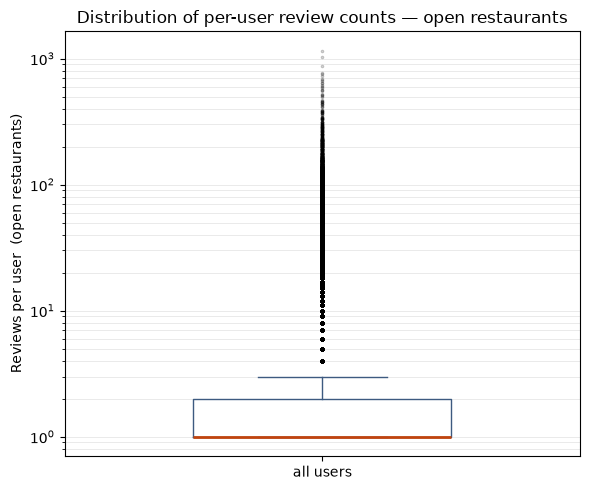

In [18]:
summary = counts.describe(percentiles=[.10, .25, .50, .75, .90, .95, .99])
summary.loc["std"]   = counts.std()
summary.loc["var"]   = counts.var()
summary.loc["skew"]  = counts.skew()
summary.loc["sum"]   = counts.sum()          # total reviews on open restaurants
print(f"users with >=1 review of an open restaurant: {len(counts):,}")
print("-" * 60)
print(summary.round(2).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(
    counts,
    vert=True,
    widths=0.5,
    showfliers=True,
    flierprops=dict(marker=".", markersize=3, alpha=0.25),
    medianprops=dict(color="#c1440e", linewidth=2),
    boxprops=dict(color="#3d5a80"),
    whiskerprops=dict(color="#3d5a80"),
    capprops=dict(color="#3d5a80"),
)
ax.set_yscale("log")
ax.set_ylabel("Reviews per user  (open restaurants)")
ax.set_xticks([1])
ax.set_xticklabels(["all users"])
ax.set_title("Distribution of per-user review counts — open restaurants")
ax.grid(axis="y", which="both", color="0.9", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Averaage amount of reviews out of all users is approximately 3 reviews made per user**

## Next we want to explore indepth with a state: CALIFORNIA 

Steps of Our analysis:
- First we want to understand the data and see how we are goign to find certain preferences and each **state** or each **city** may have in terms of food.
- Second understaing if reviewers have individual preferences of cuisines or how they like their food which may influence and reveal biased within rating of restaurants.
- **Ultimately** we want to be able to predict the preference of an individual reviewer to see what their rating will be or what their liking will be if another restaurant within our list is presented to them

In [19]:
df_california = df[df["state"] == "CA"]
print(f"Shape of California data frame: {df_california.shape}")
print("-"*1000)
print(df_california.info())

Shape of California data frame: (167698, 16)
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# NOTE: Each row is a review

### Possible later to utilize tip data to help us further understand a user's preference|

In [20]:
df_california["city"].value_counts()

city
Santa Barbara     130298
Goleta             19514
Carpinteria         9376
Isla Vista          4292
Montecito           2935
Summerland          1110
Santa  Barbara       147
Truckee               26
Name: count, dtype: int64

In [21]:
df_california_stats = (
    df_california.groupby("city")
    .agg(
        avg_review_stars=("review_stars", "mean"),
        n_reviews=("review_stars", "size"),
        n_businesses=("business_id", "nunique")
    )
    .sort_values(by="avg_review_stars", ascending=False)
)
df_california_stats["avg_review_stars"] = df_california_stats["avg_review_stars"].round(2)
df_california_stats

,avg_review_stars,n_reviews,n_businesses
city,,,
Truckee,4.77,26,1
Santa Barbara,4.08,147,1
Santa Barbara,4.03,130298,446
Carpinteria,3.94,9376,58
Montecito,3.90,2935,20
Summerland,3.88,1110,5
Goleta,3.86,19514,116
Isla Vista,3.79,4292,21


### Narrowing down the analysis to specificially see Santabarbra. 

In [22]:
df_santa_barbara = df_california[df_california["city"] == "Santa Barbara"]
df_santa_barbra_stats = (
    df_santa_barbara.groupby("name")
    .agg(
        avg_review=("review_stars", "mean"),
        n_review=("review_stars", "size")
    )
    .sort_values(by = "n_review", ascending=False)
)
df_santa_barbra_stats["avg_review"] = df_santa_barbra_stats["avg_review"].round(2)
df_santa_barbra_stats

,avg_review,n_review
name,,
Los Agaves,4.44,4718
Brophy Bros - Santa Barbara,4.06,3003
Boathouse at Hendry's Beach,4.03,2588
Santa Barbara Shellfish Company,3.91,2444
Mesa Verde,4.68,1862
...,...,...
Pueblo Pollo,2.40,5
Harbor of Santa Barbara Inc,3.60,5
John Dunn Gourmet Dining Room,4.00,5


In [23]:
#Finding useful reviews and doing a word count analysis
df_useful = query("""
    SELECT         
    (least(length(r.text), 3000) // 100) * 100 AS len_floor,
    count(*) AS n_reviews,
    round(avg(length(r.text))) AS avg_char_len,
    round(avg(r.useful), 3) AS avg_useful,
    round(avg(r.funny),  3) AS avg_funny,
    round(avg(r.cool),   3) AS avg_cool,
    round(avg((r.useful >= 1)::int), 3) AS pct_got_useful
    FROM review.review as r
    JOIN business.business AS b on b.business_id = r.business_id
    WHERE b.is_open = 1 AND b.categories ILIKE '%Restaurant%'
    Group BY len_floor
    ORDER BY len_floor
""")
df_useful

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,len_floor,n_reviews,avg_char_len,avg_useful,avg_funny,avg_cool,pct_got_useful
0,0,122483,86.0,0.300,0.089,0.137,0.201
1,100,725088,149.0,0.351,0.092,0.162,0.233
2,200,637398,248.0,0.494,0.126,0.227,0.302
3,300,500435,347.0,0.654,0.168,0.308,0.362
4,400,380359,447.0,0.821,0.224,0.393,0.418
5,500,290621,547.0,0.994,0.275,0.483,0.467
6,600,224182,647.0,1.168,0.334,0.576,0.508
7,700,175933,748.0,1.365,0.404,0.693,0.545
8,800,140090,847.0,1.566,0.477,0.819,0.580
9,900,110615,947.0,1.662,0.530,0.894,0.583


### Narrowing it down to Los Agaves restaurant to look at data to see a reviewer data on that restaurant. 

In [24]:
df_los_agaves = df_santa_barbara[df_santa_barbara["name"] == "Los Agaves"]
print(f"Shape of data: {df_los_agaves.shape}")
print("-"*1000)
print(f"average rating: {df_los_agaves["review_stars"].mean().round(2)}")
print("-"*1000)
print(f"number of unique reviewers: {df_los_agaves["user_id"].nunique()}")
print("-"*1000)
print(f"lowest reviews: {df_los_agaves.sort_values("review_stars", ascending=True).iloc[0]}")
print("-"*1000)
df_los_agaves.head(5)

Shape of data: (4718, 16)
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

,business_id,name,city,state,business_avg_stars,business_review_count,review_id,review_stars,review_date,review_text,user_id,user_name,user_avg_stars,fans,business_tip_count,business_checkin_count
132049,yPSejq3_erxo9zdVYTBnZA,Los Agaves,Santa Barbara,CA,4.5,3834,IROxv2RFznOB5dC_lOR1dQ,5.0,2017-05-06 07:07:03,"Los Agaves is delicious, my wife and I eat the...",-PR4DAFokzcZ4VWPMXBtag,Eric,4.12,0,526,6356
132122,yPSejq3_erxo9zdVYTBnZA,Los Agaves,Santa Barbara,CA,4.5,3834,Ozqf6qGDFcbZockohjN9gQ,5.0,2014-08-18 02:57:41,My girlfriend and I went to the mill pass loca...,ENjbu1Oj7comiWdaTelTDA,Mathew,4.25,0,526,6356
132403,yPSejq3_erxo9zdVYTBnZA,Los Agaves,Santa Barbara,CA,4.5,3834,t_MaUMx_Hys9keIuh-i3DQ,5.0,2014-05-13 18:55:17,"Honestly, the best Mexican food in Santa Barba...",KQP6X0CcUEus1fkED2dDFw,Whitney,3.70,1,526,6356
150633,yPSejq3_erxo9zdVYTBnZA,Los Agaves,Santa Barbara,CA,4.5,3834,9QW7FQMGZZSlX4KT7Ro18w,5.0,2018-07-20 18:48:02,This place is absolutely amazing. Came here ...,7WstoFD61HQ7_mC63L_Vpw,Thea,4.09,3,526,6356
150642,yPSejq3_erxo9zdVYTBnZA,Los Agaves,Santa Barbara,CA,4.5,3834,4Xn8P89D1HdHnI8mdL0QnA,5.0,2014-12-10 04:05:47,Absolutely delicious!! This is going to be a r...,_IS7_byZmjvlcBP1MMtwQQ,Rob,3.00,0,526,6356


### Now I want to get information on the lowest review. Since the average star rating was 4.5 for the store, I am curious as to what this person said and why he rated the food so low. This is important to further look into, because we need to understand why low reviewers rate a restaurant super low, despite the average star_review being high. 

In [25]:
df_los_agaves.sort_values("review_stars", ascending=True).iloc[0]

business_id                                          vj6AetpADpHOYtMRZsXX3g
name                                                             Los Agaves
city                                                          Santa Barbara
state                                                                    CA
business_avg_stars                                                      4.0
business_review_count                                                   807
review_id                                            TSd-QtjghAXCM7rVEEuczA
review_stars                                                            1.0
review_date                                             2020-06-27 17:42:45
review_text               I tried to find contact information for the ma...
user_id                                              uSVjiav9mjc46Ow3G8Yq8g
user_name                                                            Daniel
user_avg_stars                                                         3.75
fans        

# Los Agaves Lowest Reviewer Analysis

In [26]:
df_george = query(f"""
    SELECT
        u.user_id, u.name AS user_name, u.average_stars AS user_avg_stars,
        u.review_count AS user_review_count, u.fans, u.elite,
        u.useful AS user_useful_total, u.funny AS user_funny_total, u.cool AS user_cool_total,
        r.review_id, r.stars AS review_stars, r.useful, r.funny, r.cool,
        r.date AS review_date, r.text AS review_text,
        b.business_id, b.name AS business_name, b.city, b.state, b.categories,
        b.stars AS business_avg_stars, b.review_count AS business_review_count, b.is_open
    FROM review.review AS r
    JOIN business.business AS b ON b.business_id = r.business_id
    JOIN users.users     AS u ON u.user_id     = r.user_id
    WHERE r.user_id = (
        SELECT user_id FROM review.review WHERE review_id = '{"dTd10dO7ZD4v1ALbQROqhg"}'
    )
    AND b.is_open = 1
    AND b.categories ILIKE '%Restaurant%'
    ORDER BY r.date
""")

pd.set_option("display.max_columns", None)  
print(f"shape: {df_george.shape}")
print("-"*1000)
print(f"lowest star rating: {df_george["review_stars"].min()},  highest star rating: {df_george["review_stars"].max()}")
print("-"*1000)
print(df_george["user_avg_stars"].mean())
print("-"*1000)
print(df_george.info())
print("-"*1000)
df_george.head(10)

shape: (3, 24)
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

,user_id,user_name,user_avg_stars,user_review_count,fans,elite,user_useful_total,user_funny_total,user_cool_total,review_id,review_stars,useful,funny,cool,review_date,review_text,business_id,business_name,city,state,categories,business_avg_stars,business_review_count,is_open
0,Pe_bMo1_r_ADVvX8p-dQmg,George,3.25,13,1,,7,0,4,lqRfIJsbIQ_O4LbTwh83eg,2.0,2,0,0,2014-01-29 17:18:03,Usually pretty good but today there was lipsti...,-loV4cB2Uh9TCltTRgGzWQ,Renaud's Patisserie & Bistro,Santa Barbara,CA,"Coffee & Tea, Breakfast & Brunch, Restaurants,...",4.0,379,1
1,Pe_bMo1_r_ADVvX8p-dQmg,George,3.25,13,1,,7,0,4,aqyOaEHjJ1egjB9eWYwmGg,2.0,0,0,0,2019-02-10 04:34:55,Meh. I've had four meals at The Lark. The firs...,oGDGlUbOjHxmmCh8ZYcDCg,The Lark,Santa Barbara,CA,"Nightlife, Bars, Cocktail Bars, Food, American...",4.0,1520,1
2,Pe_bMo1_r_ADVvX8p-dQmg,George,3.25,13,1,,7,0,4,dTd10dO7ZD4v1ALbQROqhg,1.0,0,0,0,2021-04-29 20:12:06,There was a time when I thought this was some ...,yPSejq3_erxo9zdVYTBnZA,Los Agaves,Santa Barbara,CA,"Mexican, Restaurants",4.5,3834,1


In [27]:
for i in range(df_george.shape[0]):
    print(df_george["review_text"].iloc[i])
    print("-"*1000)

Usually pretty good but today there was lipstick on the coffee cup (obviously not mine) and mold on the grapes. No compensation. Just an apology. Pretty expensive and gross experience.
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### NOTE: It seems this person is a tough reviewer, especially towards the service. Their review on a restaurant highly depends on the waiter giving a good impression, along with consistency. If the restaurant might be having an off day, the person would critique the restaurants flaw for the day. Moreover, it seems the revieews are only made whenthere is something done wrong from the restaurant. 

### Helpfulness: 2 people found his review on Renaud's Patisserie & Bistro useful. **investigate what makes a review useful**

### **USING LightGBM classifier** for classifying helpful reviews 
- Stronger: fine-tune DistilBERT/RoBERTa for binary classification on the text alone.
- Evaluation: temporal split; report PR-AUC / F1, not accuracy (59% zeros makes accuracy meaningless). Baselines: predict-majority, length-only, fans-only.


# Machine Learning: Collaboritive Filtering & NLP


### STEP 1 Prepping the data (Using TF-IDF)